In [1]:
# All Newman-alpha-scheme machinery (centering, Jacobians, LCF/spectral-gap
# computation, sync/async updates, MLE fitting, SBM data generation) now
# lives in utils.py -- see that file for full documentation of each function.
# utils.py must be in the same directory as this notebook (or on sys.path).
from utils import *

import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

# Backward Cycle

In [2]:
n      = 20
W      = np.zeros((n, n))
m_min, m_max = (10000000, 50000000)
np.random.seed(2026)
plays  = np.random.randint(m_min, m_max, n)
for i in range(n - 1):
    W[i, i + 1] = plays[i]
W[n - 1, 0] = plays[-1]

win_list  = {i: [np.where(W[i]  > 0)[0], W[i]  [np.where(W[i]  > 0)[0]]] for i in range(n)}
loss_list = {i: [np.where(W[:,i]> 0)[0], W[:,i][np.where(W[:,i]> 0)[0]]] for i in range(n)}
mle  = newman_fpi(win_list, loss_list, maxiter=100000, sync='none', alpha=0)

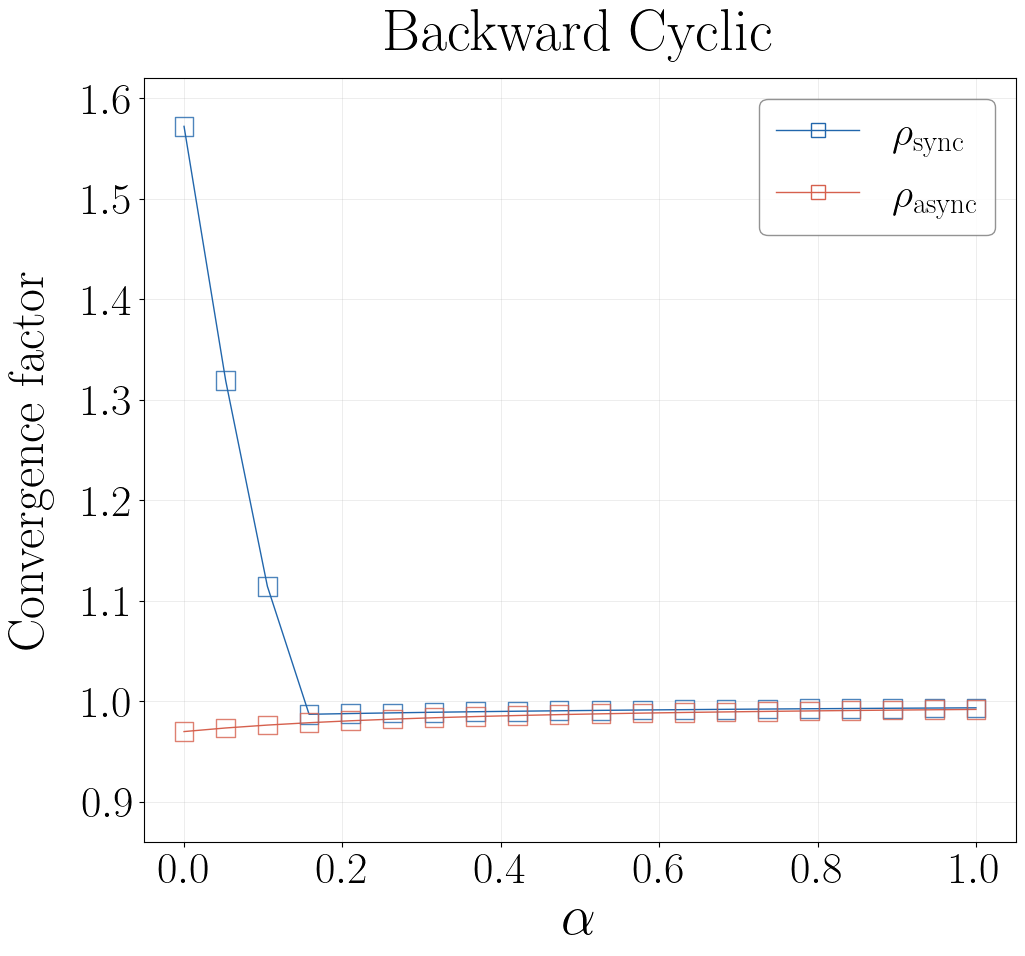

In [3]:
# --- Shared style config ---
FIG_W, FIG_H  = 10.2, 9.5
TITLE_FS      = 50-8
LABEL_FS      = 40
TICK_FS       = 32
LEGEND_FS     = 30
MARKER_S      = 180

COLOR_SYNC    = '#2166AC'   # blue  -- sync
COLOR_ASYNC   = '#D6604D'   # red   -- async

rc('text', usetex=True)
rc('font', family='serif')
rc('axes', linewidth=0.8)

alpha_set = np.linspace(0, 1, 20)

rates_f = np.array([get_lcf(W, mle, alpha, sync='full') for alpha in alpha_set])
rates_a = np.array([get_lcf(W, mle, alpha, sync='none') for alpha in alpha_set])

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.scatter(alpha_set, rates_f,
           color=COLOR_SYNC,  s=MARKER_S, marker='s', zorder=3, alpha=0.8, facecolors='none')
ax.plot(alpha_set, rates_f, color=COLOR_SYNC, linewidth=1, zorder=2)

ax.scatter(alpha_set, rates_a,
           color=COLOR_ASYNC, s=MARKER_S, marker='s', zorder=3, alpha=0.8, facecolors='none')
ax.plot(alpha_set, rates_a, color=COLOR_ASYNC, linewidth=1, zorder=2)

ax.set_title(r'$\mathrm{Backward\ Cyclic}$', fontsize=TITLE_FS, pad=20)
ax.set_xlabel(r'$\alpha$', fontsize=LABEL_FS)
# --- Referee comment: unify y-axis label from 'Rate' to 'Convergence factor' ---
ax.set_ylabel(r'Convergence factor', fontsize=LABEL_FS-4, labelpad=20)
plt.ylim(0.86, 1.62)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
ax.grid(True, linewidth=0.4, alpha=0.4)

legend_elements = [
    Line2D([0], [0], color=COLOR_SYNC,  marker='s', markersize=10,
           markerfacecolor='none', markeredgecolor=COLOR_SYNC,
           linestyle='-', linewidth=1, label=r'$\rho_{\mathrm{sync}}$'),
    Line2D([0], [0], color=COLOR_ASYNC, marker='s', markersize=10,
           markerfacecolor='none', markeredgecolor=COLOR_ASYNC,
           linestyle='-', linewidth=1, label=r'$\rho_{\mathrm{async}}$'),
]
ax.legend(handles=legend_elements, fontsize=LEGEND_FS, loc='upper right',
          framealpha=0.85, edgecolor='gray')

plt.tight_layout(pad=0.5)
plt.savefig('backward_cycle.pdf', bbox_inches='tight')
plt.show()